<a href="https://colab.research.google.com/github/hemanthtadikonda/my-webpage/blob/main/EP_04_EDA%26FE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q kaggle pandera pandas numpy matplotlib seaborn scikit-learn
#

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.9/292.9 kB 5.4 MB/s eta 0:00:00


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d carrie1/ecommerce-data
!unzip ecommerce-data.zip

Dataset URL: https://www.kaggle.com/datasets/carrie1/ecommerce-data
License(s): unknown
  0% 0.00/7.20M [00:00<?, ?B/s]
100% 7.20M/7.20M [00:00<00:00, 722MB/s]
Archive:  ecommerce-data.zip
  inflating: data.csv                


In [ ]:
import pandas as pd
import numpy as np
import pandera as pa
from pandera import Column, DataFrameSchema, Check
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('data.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
schema = DataFrameSchema({
    "InvoiceNo": Column(str),
    "StockCode": Column(str),
    "Description": Column(str, nullable=True),
    "Quantity": Column(int),
    "InvoiceDate": Column(str),
    "UnitPrice": Column(float, Check.ge(0)),
    "CustomerID": Column(float, nullable=True),
    "Country": Column(str)
})

schema.validate(df.sample(10000), lazy=True)


/usr/local/lib/python3.12/dist-packages/pandera/_pandas_deprecated.py:149: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
180463,552320,21559,STRAWBERRY LUNCH BOX WITH CUTLERY,12,5/9/2011 8:26,2.55,13985.0,United Kingdom
296725,562930,23327,HANGING CLEAR MINI BOTTLE,48,8/10/2011 16:01,0.63,14209.0,United Kingdom
44436,540176,21240,BLUE POLKADOT CUP,96,1/5/2011 12:40,0.72,17511.0,United Kingdom
344549,567077,23321,SMALL WHITE HEART OF WICKER,2,9/16/2011 12:34,1.65,18122.0,United Kingdom
485325,577595,82580,BATHROOM METAL SIGN,1,11/20/2011 16:12,0.55,16399.0,United Kingdom
...,...,...,...,...,...,...,...,...
310221,564170,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,8/23/2011 13:59,0.65,17696.0,United Kingdom
456789,575713,23433,HANGING QUILTED PATCHWORK APPLES,12,11/10/2011 17:49,0.83,13817.0,Germany
435076,574074,21446,12 RED ROSE PEG PLACE SETTINGS,1,11/2/2011 15:33,2.46,NaN,United Kingdom
307722,563925,23295,SET OF 12 MINI LOAF BAKING CASES,1,8/21/2011 14:42,0.83,13610.0,United Kingdom


In [ ]:
# Parse dates
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

# Drop duplicates
df = df.drop_duplicates()

# Remove missing CustomerIDs
df = df.dropna(subset=["CustomerID"])

# Convert negative quantity (returns) → absolute value and mark them
df["is_return"] = df["Quantity"] < 0
df["Quantity"] = df["Quantity"].abs()

# Remove zero/negative prices
df = df[df["UnitPrice"] > 0]

# Create TotalPrice
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_return,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0
is_return,0
TotalPrice,0


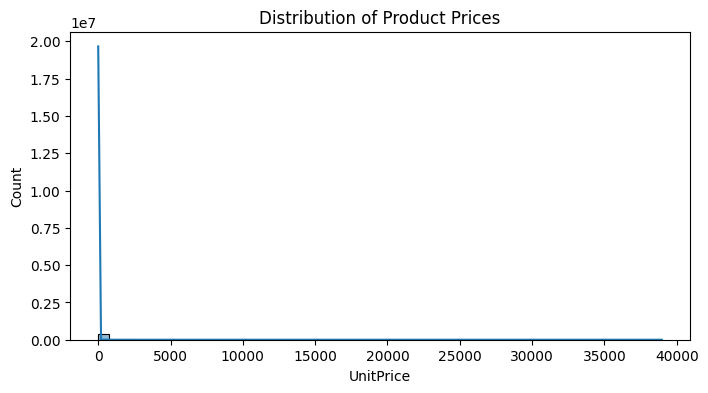

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['UnitPrice'], bins=50, kde=True)
plt.title("Distribution of Product Prices")
plt.show()


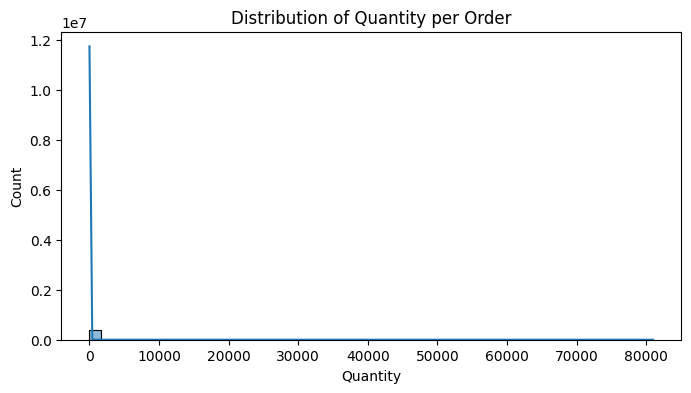

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Quantity'], bins=50, kde=True)
plt.title("Distribution of Quantity per Order")
plt.show()


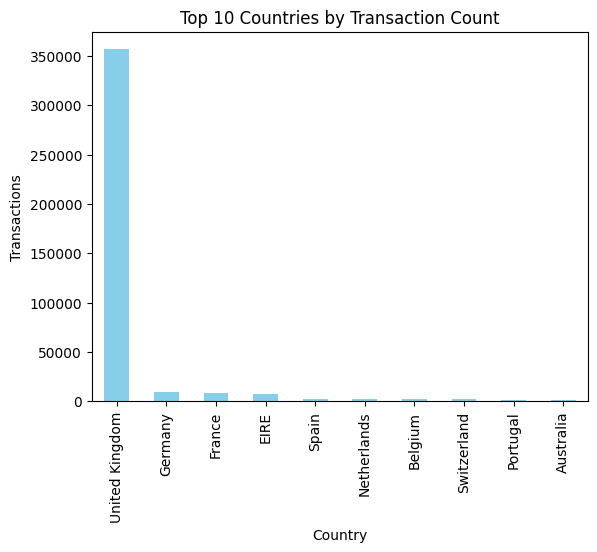

In [ ]:
df['Country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Countries by Transaction Count")
plt.ylabel("Transactions")
plt.show()


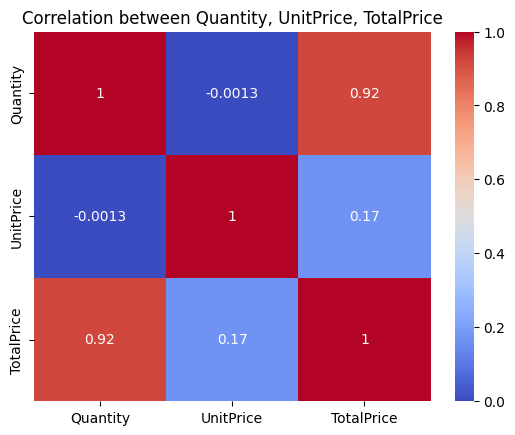

In [ ]:
corr = df[['Quantity','UnitPrice','TotalPrice']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation between Quantity, UnitPrice, TotalPrice")
plt.show()


In [ ]:
ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (ref_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                              # Frequency
    "TotalPrice": "sum"                                  # Monetary
}).rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
}).reset_index()

rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2,154367.20
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [ ]:
rfm.to_csv('rfm_data.csv', index=False)
df.to_csv('cleaned_data.csv', index=False)